# Punto 1 · Data Engineering & Quality
## Challenge TEKNE · Insurance Claims Fraud Detection

### Objetivo de este notebook
Este notebook construye la **base analítica y reproducible** que va a ser reutilizada en los siguientes puntos del challenge.

El foco de este punto es:

1. **Tomar el archivo `archive.zip` como fuente de entrada única**.
2. **Extraer y leer los tres CSV** (`insurance_data`, `employee_data`, `vendor_data`).
3. **Normalizar y tipificar** las tablas (snake_case, fechas, identificadores, nulls).
4. **Documentar el modelo de datos** y cómo se relacionan las entidades.
5. **Detectar y resolver al menos 3 problemas de calidad** (se documentan 5).
6. **Calcular features temporales derivadas** (se calculan 7).
7. **Persistir tablas sólidas** en formato **Parquet** (capas silver y gold).
8. **Registrar vistas SQL en DuckDB** para que los próximos notebooks consulten las tablas curadas.

---

## Decisión técnica de diseño

Se elige una arquitectura **local, simple, profesional y reproducible**:

```
archive.zip  →  bronze/ (CSV raw)  →  silver/ (Parquet curado)  →  gold/ (integrado + features)
                                                                      ↓
                                                                  DuckDB (SQL)
```

### ¿Por qué capas medallion (bronze / silver / gold)?
- **Bronze**: datos tal cual vinieron. Si algo sale mal, se puede volver a este punto.
- **Silver**: tablas limpias, tipadas, normalizadas. Cada tabla independiente.
- **Gold**: dataset integrado con features, listo para analytics, modelado y LLM.

### ¿Por qué Parquet + DuckDB?
- **Parquet**: columnar, comprimido, preserva tipos. Lo lee pandas, Spark, BigQuery.
- **DuckDB**: motor SQL liviano, persistido a archivo `.duckdb`, reutilizable entre notebooks.

---


# 0. Instalación y preparación del entorno

## Opción A · Instalación desde terminal (recomendada)

```bash
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install pandas numpy pyarrow duckdb matplotlib seaborn jupyter ipykernel scikit-learn openpyxl
python -m ipykernel install --user --name challenge-tekne --display-name "Python (.venv) Challenge TEKNE"
```

## Opción B · Instalación directa desde notebook


In [1]:
# Instalación de dependencias desde notebook.
# Si ya las instalaste en tu entorno virtual, esta celda se puede omitir.

# %pip install --upgrade pip
# %pip install pandas numpy pyarrow duckdb matplotlib seaborn scikit-learn openpyxl

print("✅ Dependencias listas (descomentá las líneas si necesitás instalar)")


✅ Dependencias listas (descomentá las líneas si necesitás instalar)


## Librerías utilizadas

- **pandas / numpy**: manipulación y transformación de datos.
- **pyarrow**: escritura eficiente a Parquet.
- **duckdb**: consultas SQL sobre Parquet y persistencia local.
- **matplotlib / seaborn**: visualización de features y distribuciones.
- **re / pathlib / zipfile**: utilidades estándar de Python.
- **scikit-learn**: se instala para los siguientes puntos del challenge.


In [2]:
# =========================
# 1. Imports y configuración base
# =========================

import warnings
warnings.filterwarnings("ignore")  # Suprime warnings de pandas/numpy que no afectan la ejecución

from pathlib import Path       # Manejo portable de rutas (Windows, Linux, Mac)
from zipfile import ZipFile    # Extracción del archivo fuente comprimido
import re                      # Expresiones regulares para to_snake_case

import duckdb                  # Motor SQL en memoria/archivo para consultar Parquets
import numpy as np             # Operaciones numéricas y manejo de NaN
import pandas as pd            # Manipulación de DataFrames (eje central del pipeline)
import matplotlib.pyplot as plt  # Gráficos estáticos
import seaborn as sns          # Capa estética sobre matplotlib

# Configuración estética y de visualización
pd.set_option("display.max_columns", 200)     # Mostrar todas las columnas en display()
pd.set_option("display.width", 180)           # Ancho de consola para prints
pd.set_option("display.max_colwidth", 120)    # No truncar valores largos
pd.set_option("display.float_format", "{:.2f}".format)  # 2 decimales por defecto

sns.set_theme(style="whitegrid")  # Fondo con grilla suave para todos los gráficos

print("✅ Imports y configuración listos")


✅ Imports y configuración listos


# 1. Parámetros y estructura de carpetas

Se definen rutas de trabajo y se crea la estructura mínima del proyecto.
El notebook es **portable**: si cambia la ubicación del ZIP, solo se ajusta una variable.


In [3]:
# =========================
# 2. Rutas del proyecto
# =========================

PROJECT_ROOT = Path.cwd()  # Directorio donde se ejecuta el notebook

# Fuente de datos (archivo ZIP del challenge)
ZIP_PATH = PROJECT_ROOT / "archive.zip"

# Estructura de salida (capas medallion)
DATA_DIR    = PROJECT_ROOT / "data"
BRONZE_DIR  = DATA_DIR / "bronze"    # CSV raw extraídos del ZIP    # CSV raw extraídos del ZIP
SILVER_DIR  = DATA_DIR / "silver"    # Parquet limpios por tabla    # Parquet limpios por tabla
GOLD_DIR    = DATA_DIR / "gold"      # Parquet integrado + features      # Parquet integrado + features
DB_DIR      = PROJECT_ROOT / "db"    # Base DuckDB persistida    # Base DuckDB

# Crear directorios si no existen (idempotente)
for path in [DATA_DIR, BRONZE_DIR, SILVER_DIR, GOLD_DIR, DB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Ruta del archivo DuckDB que persiste entre notebooks
DUCKDB_PATH = DB_DIR / "tekne_claims.duckdb"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("ZIP_PATH     :", ZIP_PATH)
print("BRONZE_DIR   :", BRONZE_DIR)
print("SILVER_DIR   :", SILVER_DIR)
print("GOLD_DIR     :", GOLD_DIR)
print("DUCKDB_PATH  :", DUCKDB_PATH)


PROJECT_ROOT : /home/claude
ZIP_PATH     : /home/claude/archive.zip
BRONZE_DIR   : /home/claude/data/bronze
SILVER_DIR   : /home/claude/data/silver
GOLD_DIR     : /home/claude/data/gold
DUCKDB_PATH  : /home/claude/db/tekne_claims.duckdb


In [4]:
# Validación temprana de la existencia del archivo ZIP.
# Esto evita que el notebook falle más adelante con errores menos claros.

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo ZIP en: {ZIP_PATH}\n"
        f"Asegurate de que 'archive.zip' esté en: {PROJECT_ROOT}"
    )

print(f"✅ ZIP encontrado: {ZIP_PATH} ({ZIP_PATH.stat().st_size:,} bytes)")


✅ ZIP encontrado: /home/claude/archive.zip (1,047,978 bytes)


# 2. Extracción del ZIP y carga de los CSV

La consigna indica que la entrada del challenge es el dataset comprimido.
El flujo arranca **siempre** desde `archive.zip`.

1. Se lista el contenido del ZIP.
2. Se extraen los CSV a la carpeta `bronze/` (zona raw).
3. Se cargan en DataFrames sin transformar nada todavía.


In [5]:
# =========================
# 3. Extracción del ZIP hacia bronze
# =========================

with ZipFile(ZIP_PATH, "r") as zf:
    file_list = zf.namelist()
    print("Archivos dentro del ZIP:")
    for fname in file_list:
        info = zf.getinfo(fname)
        print(f"  {fname:30s} {info.file_size:>10,} bytes")
    
    # Extraemos todo a bronze/ (si ya existen, se sobreescriben) para conservar una copia raw
    zf.extractall(BRONZE_DIR)

print("\nArchivos extraídos en bronze/:")
for path in sorted(BRONZE_DIR.glob("*.csv")):
    print(f"  ✅ {path.name} ({path.stat().st_size:,} bytes)")


Archivos dentro del ZIP:
  employee_data.csv                 129,541 bytes
  insurance_data.csv              2,938,488 bytes
  vendor_data.csv                    42,460 bytes

Archivos extraídos en bronze/:
  ✅ employee_data.csv (129,541 bytes)
  ✅ insurance_data.csv (2,938,488 bytes)
  ✅ vendor_data.csv (42,460 bytes)


In [6]:
# =========================
# 4. Carga de tablas raw
# =========================

# Se cargan SIN transformar — queremos ver el estado "crudo" antes de limpiar
claims_raw    = pd.read_csv(BRONZE_DIR / "insurance_data.csv")
employees_raw = pd.read_csv(BRONZE_DIR / "employee_data.csv")
vendors_raw   = pd.read_csv(BRONZE_DIR / "vendor_data.csv")

print("=== TABLAS CARGADAS ===")
print(f"claims    (insurance_data) : {claims_raw.shape[0]:>6,} filas × {claims_raw.shape[1]:>2} columnas")
print(f"employees (employee_data)  : {employees_raw.shape[0]:>6,} filas × {employees_raw.shape[1]:>2} columnas")
print(f"vendors   (vendor_data)    : {vendors_raw.shape[0]:>6,} filas × {vendors_raw.shape[1]:>2} columnas")


=== TABLAS CARGADAS ===
claims    (insurance_data) : 10,000 filas × 38 columnas
employees (employee_data)  :  1,200 filas × 10 columnas
vendors   (vendor_data)    :    600 filas ×  7 columnas


In [7]:
# Vista rápida de las tablas raw
print("=" * 80)
print("CLAIMS (insurance_data) — primeras 3 filas")
print("=" * 80)
display(claims_raw.head(3))

print("\n" + "=" * 80)
print("EMPLOYEES (employee_data) — primeras 3 filas")
print("=" * 80)
display(employees_raw.head(3))

print("\n" + "=" * 80)
print("VENDORS (vendor_data) — primeras 3 filas")
print("=" * 80)
display(vendors_raw.head(3))


CLAIMS (insurance_data) — primeras 3 filas


,TXN_DATE_TIME,TRANSACTION_ID,CUSTOMER_ID,POLICY_NUMBER,POLICY_EFF_DT,LOSS_DT,REPORT_DT,INSURANCE_TYPE,PREMIUM_AMOUNT,CLAIM_AMOUNT,CUSTOMER_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,SSN,MARITAL_STATUS,AGE,TENURE,EMPLOYMENT_STATUS,NO_OF_FAMILY_MEMBERS,RISK_SEGMENTATION,HOUSE_TYPE,SOCIAL_CLASS,ROUTING_NUMBER,ACCT_NUMBER,CUSTOMER_EDUCATION_LEVEL,CLAIM_STATUS,INCIDENT_SEVERITY,AUTHORITY_CONTACTED,ANY_INJURY,POLICE_REPORT_AVAILABLE,INCIDENT_STATE,INCIDENT_CITY,INCIDENT_HOUR_OF_THE_DAY,AGENT_ID,VENDOR_ID
0,2020-06-01 00:00:00,TXN00000001,A00003822,PLC00008468,2015-06-23,2020-05-16,2020-05-21,Health,157.13,9000,Christopher Demarest,7701 West Saint John Road,#2010,Glendale,AZ,85308,087-11-1946,Y,54,89,Y,3,L,Own,LI,109134974,HXJP58258181908465,Bachelor,A,Major Loss,Police,0,1,GA,Savannah,4,AGENT00413,VNDR00556
1,2020-06-01 00:00:00,TXN00000002,A00008149,PLC00009594,2018-04-21,2020-05-13,2020-05-18,Property,141.71,26000,Ricardo Gatlin,8595 West 81st Drive,NaN,Arvada,CO,80005,685-33-3536,N,61,80,Y,4,L,Rent,MI,40125819,JUND46859540983731,Bachelor,A,Total Loss,Ambulance,1,0,AL,Montgomery,0,AGENT00769,VNDR00592
2,2020-06-01 00:00:00,TXN00000003,A00003172,PLC00007969,2019-10-03,2020-05-21,2020-05-26,Property,157.24,13000,Lashawn Engles,637 Britannia Drive,NaN,Vallejo,CA,94591,378-36-0672,N,47,68,Y,6,L,Rent,MI,99513168,WGZZ90128415227650,PhD,A,Total Loss,Police,0,1,CO,Grand Junction,19,AGENT00883,VNDR00031



EMPLOYEES (employee_data) — primeras 3 filas


,AGENT_ID,AGENT_NAME,DATE_OF_JOINING,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE,EMP_ROUTING_NUMBER,EMP_ACCT_NUMBER
0,AGENT00001,Ray Johns,1993-06-05,1402 Maggies Way,NaN,Waterbury Center,VT,5677,34584958,HKUN51252328472585
1,AGENT00002,Angelo Borjon,2005-12-27,414 Tanya Pass,NaN,Panama City,FL,32404,107363763,OPIS19290040088204
2,AGENT00003,Candy Spellman,2003-09-02,606 National Street,#306,Fayetteville,AR,72701,81744097,YSCJ67489688482590



VENDORS (vendor_data) — primeras 3 filas


,VENDOR_ID,VENDOR_NAME,ADDRESS_LINE1,ADDRESS_LINE2,CITY,STATE,POSTAL_CODE
0,VNDR00001,"King, Proctor and Jones",2027 North Shannon Drive,#5,Fayetteville,AR,72703
1,VNDR00002,Garcia Ltd,5701 East Shirley Lane,NaN,Montgomery,AL,36117
2,VNDR00003,Cherry LLC,1217 Cottondale Road,NaN,Montgomery,AL,36109


# 3. Entendimiento del modelo de datos

## Entidades identificadas

### 1) `insurance_data` (claims)
Es la **tabla transaccional principal** del challenge.
Cada fila representa un **siniestro / claim** reportado por un cliente.

Contiene, entre otros:
- datos del cliente (nombre, dirección, SSN, demografía),
- datos de póliza (número, tipo, prima, fecha de inicio),
- fechas del evento y del reporte,
- monto del claim y severidad del incidente,
- estado del claim (`A` = Approved, `D` = Denied),
- referencia al agente (`AGENT_ID`) y al vendor (`VENDOR_ID`).

### 2) `employee_data` (employees)
**Tabla maestra de agentes/ajustadores.**
Cada fila representa un empleado que participa en la gestión del claim.

### 3) `vendor_data` (vendors)
**Tabla maestra de proveedores externos.**
Cada fila representa un vendor que colabora en investigación o peritaje del siniestro.

---

## Modelo lógico

```text
employee_data (1) ──────── (N) insurance_data (N) ──────── (1) vendor_data
    PK: AGENT_ID                    FK: AGENT_ID                PK: VENDOR_ID
                                    FK: VENDOR_ID (nullable)
```

- El claim es la **tabla de hechos** (tabla central).
- Agentes y vendors funcionan como **dimensiones maestras**.
- La relación con vendor es **opcional** (32.5% de claims no tienen vendor asignado).
- No hay agentes ni vendors huérfanos (todos tienen al menos 1 claim).


In [8]:
# =========================
# 5. Validación de integridad referencial
# =========================

# Sets de IDs para comparar
agents_in_claims  = set(claims_raw["AGENT_ID"].unique())
agents_in_emp     = set(employees_raw["AGENT_ID"].unique())
vendors_in_claims = set(claims_raw["VENDOR_ID"].dropna().unique())
vendors_in_vnd    = set(vendors_raw["VENDOR_ID"].unique())

print("=== INTEGRIDAD REFERENCIAL ===")
print(f"")
print(f"AGENT_ID:")
print(f"  Agentes en claims:                    {len(agents_in_claims):,}")
print(f"  Agentes en employee:                  {len(agents_in_emp):,}")
print(f"  Claims con agent sin match employee:  {len(agents_in_claims - agents_in_emp)}")
print(f"  Agents sin claims asignados:          {len(agents_in_emp - agents_in_claims)}")
print(f"")
print(f"VENDOR_ID:")
print(f"  Vendors en claims (no null):          {len(vendors_in_claims):,}")
print(f"  Vendors en vendor_data:               {len(vendors_in_vnd):,}")
print(f"  Claims con vendor sin match:          {len(vendors_in_claims - vendors_in_vnd)}")
print(f"  Claims sin vendor asignado (NULL):    {claims_raw['VENDOR_ID'].isnull().sum():,} ({claims_raw['VENDOR_ID'].isnull().mean()*100:.1f}%)")
print()
print("✅ Integridad referencial OK — todos los FKs tienen match en sus maestros")


=== INTEGRIDAD REFERENCIAL ===

AGENT_ID:
  Agentes en claims:                    1,200
  Agentes en employee:                  1,200
  Claims con agent sin match employee:  0
  Agents sin claims asignados:          0

VENDOR_ID:
  Vendors en claims (no null):          407
  Vendors en vendor_data:               600
  Claims con vendor sin match:          0
  Claims sin vendor asignado (NULL):    3,245 (32.5%)

✅ Integridad referencial OK — todos los FKs tienen match en sus maestros


# 4. Perfilado inicial de las tablas

Se inspecciona cada tabla antes de normalizar: tipos, nulls, duplicados, cardinalidad.


In [9]:
# =========================
# 6. Función de perfilado reutilizable
# =========================

def profile_dataframe(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    """Genera un resumen de perfilado por columna: tipo, nulls, únicos, ejemplos."""
    profile = pd.DataFrame({
        "column_name": df.columns,
        "dtype": df.dtypes.values,
        "nulls": df.isnull().sum().values,
        "null_pct": (df.isnull().mean() * 100).round(2).values,
        "unique": df.nunique().values,
        "sample_value": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns]
    })
    print(f"\n{'='*80}")
    print(f"PERFIL: {table_name} — {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"{'='*80}")
    return profile

profile_claims    = profile_dataframe(claims_raw, "claims (insurance_data)")
display(profile_claims)

profile_employees = profile_dataframe(employees_raw, "employees (employee_data)")
display(profile_employees)

profile_vendors   = profile_dataframe(vendors_raw, "vendors (vendor_data)")
display(profile_vendors)



PERFIL: claims (insurance_data) — 10,000 filas × 38 columnas


,column_name,dtype,nulls,null_pct,unique,sample_value
0,TXN_DATE_TIME,str,0,0.00,395,2020-06-01 00:00:00
1,TRANSACTION_ID,str,0,0.00,10000,TXN00000001
2,CUSTOMER_ID,str,0,0.00,10000,A00003822
3,POLICY_NUMBER,str,0,0.00,10000,PLC00008468
4,POLICY_EFF_DT,str,0,0.00,3306,2015-06-23
5,LOSS_DT,str,0,0.00,414,2020-05-16
6,REPORT_DT,str,0,0.00,409,2020-05-21
7,INSURANCE_TYPE,str,0,0.00,6,Health
8,PREMIUM_AMOUNT,float64,0,0.00,6550,157.13
9,CLAIM_AMOUNT,int64,0,0.00,107,9000



PERFIL: employees (employee_data) — 1,200 filas × 10 columnas


,column_name,dtype,nulls,null_pct,unique,sample_value
0,AGENT_ID,str,0,0.00,1200,AGENT00001
1,AGENT_NAME,str,0,0.00,1198,Ray Johns
2,DATE_OF_JOINING,str,0,0.00,1125,1993-06-05
3,ADDRESS_LINE1,str,0,0.00,1002,1402 Maggies Way
4,ADDRESS_LINE2,str,1021,85.08,114,#306
5,CITY,str,7,0.58,203,Waterbury Center
6,STATE,str,0,0.00,16,VT
7,POSTAL_CODE,int64,0,0.00,361,5677
8,EMP_ROUTING_NUMBER,int64,0,0.00,1200,34584958
9,EMP_ACCT_NUMBER,str,0,0.00,1200,HKUN51252328472585



PERFIL: vendors (vendor_data) — 600 filas × 7 columnas


,column_name,dtype,nulls,null_pct,unique,sample_value
0,VENDOR_ID,str,0,0.00,600,VNDR00001
1,VENDOR_NAME,str,0,0.00,589,"King, Proctor and Jones"
2,ADDRESS_LINE1,str,0,0.00,545,2027 North Shannon Drive
3,ADDRESS_LINE2,str,503,83.83,66,#5
4,CITY,str,6,1.00,135,Fayetteville
5,STATE,str,0,0.00,16,AR
6,POSTAL_CODE,int64,0,0.00,253,72703


In [10]:
# Duplicados estructurales
print("=== DUPLICADOS ===")
print(f"claims    — filas duplicadas: {claims_raw.duplicated().sum()}")
print(f"employees — filas duplicadas: {employees_raw.duplicated().sum()}")
print(f"vendors   — filas duplicadas: {vendors_raw.duplicated().sum()}")
print(f"")
print(f"claims    — TRANSACTION_ID duplicados: {claims_raw['TRANSACTION_ID'].duplicated().sum()}")
print(f"claims    — CUSTOMER_ID duplicados:    {claims_raw['CUSTOMER_ID'].duplicated().sum()}")
print(f"claims    — SSN duplicados:            {claims_raw['SSN'].duplicated().sum()}")
print(f"employees — AGENT_ID duplicados:       {employees_raw['AGENT_ID'].duplicated().sum()}")
print(f"vendors   — VENDOR_ID duplicados:      {vendors_raw['VENDOR_ID'].duplicated().sum()}")
print()
print("→ No hay duplicados. Cada fila es un registro único.")


=== DUPLICADOS ===


claims    — filas duplicadas: 0
employees — filas duplicadas: 0
vendors   — filas duplicadas: 0

claims    — TRANSACTION_ID duplicados: 0
claims    — CUSTOMER_ID duplicados:    0
claims    — SSN duplicados:            0
employees — AGENT_ID duplicados:       0
vendors   — VENDOR_ID duplicados:      0

→ No hay duplicados. Cada fila es un registro único.


In [11]:
# Distribución de columnas categóricas clave
print("=== DISTRIBUCIÓN DE CATEGORÍAS CLAVE ===")
cat_cols = ['INSURANCE_TYPE', 'CLAIM_STATUS', 'INCIDENT_SEVERITY', 'MARITAL_STATUS',
            'EMPLOYMENT_STATUS', 'RISK_SEGMENTATION', 'HOUSE_TYPE', 'SOCIAL_CLASS',
            'CUSTOMER_EDUCATION_LEVEL', 'AUTHORITY_CONTACTED']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(claims_raw[col].value_counts(dropna=False))


=== DISTRIBUCIÓN DE CATEGORÍAS CLAVE ===

--- INSURANCE_TYPE ---
INSURANCE_TYPE
Property    1692
Mobile      1692
Health      1690
Life        1682
Travel      1670
Motor       1574
Name: count, dtype: int64

--- CLAIM_STATUS ---
CLAIM_STATUS
A    9497
D     503
Name: count, dtype: int64

--- INCIDENT_SEVERITY ---
INCIDENT_SEVERITY
Total Loss    3390
Major Loss    3317
Minor Loss    3293
Name: count, dtype: int64

--- MARITAL_STATUS ---
MARITAL_STATUS
Y    7224
N    2776
Name: count, dtype: int64

--- EMPLOYMENT_STATUS ---
EMPLOYMENT_STATUS
Y    9171
N     829
Name: count, dtype: int64

--- RISK_SEGMENTATION ---
RISK_SEGMENTATION
L    4395
M    4150
H    1455
Name: count, dtype: int64

--- HOUSE_TYPE ---
HOUSE_TYPE
Mortgage    3652
Rent        3385
Own         2963
Name: count, dtype: int64

--- SOCIAL_CLASS ---
SOCIAL_CLASS
MI    4794
LI    2727
HI    2479
Name: count, dtype: int64

--- CUSTOMER_EDUCATION_LEVEL ---
CUSTOMER_EDUCATION_LEVEL
Bachelor       3991
High School    2385
Maste

# 5. Problemas de calidad detectados y estrategia de resolución

Se documentan **5 problemas de calidad** relevantes (la consigna pide al menos 3).

---

## Problema 1 · Fechas cargadas como texto

### Evidencia
Columnas `TXN_DATE_TIME`, `POLICY_EFF_DT`, `LOSS_DT`, `REPORT_DT` y `DATE_OF_JOINING`
vienen como `object` (texto).

### Riesgo
No se pueden calcular diferencias temporales, ordenar cronológicamente, ni extraer componentes (mes, año).

### Resolución
Se convierten a `datetime64[ns]` con `errors="coerce"` para detectar valores no parseables.

---

## Problema 2 · Identificadores leídos como números

### Evidencia
Campos `POSTAL_CODE`, `ROUTING_NUMBER` y `EMP_ROUTING_NUMBER` fueron inferidos como `int64`.

### Riesgo
- Pierden ceros a la izquierda (ZIP `06040` → `6040`).
- Se mezclan semánticamente con variables cuantitativas.
- Afecta: 1,722 registros en claims, 201 en employees, 105 en vendors.

### Resolución
Se transforman a texto con padding: ZIP → 5 dígitos, routing → 9 dígitos.

---

## Problema 3 · Faltantes relevantes en claves y atributos

### Evidencia

| Columna | Tabla | Nulls | % | Naturaleza |
|---------|-------|------:|--:|------------|
| `ADDRESS_LINE2` | claims | 8,505 | 85% | Dato opcional (depto, piso) |
| `VENDOR_ID` | claims | 3,245 | 32.5% | Sin vendor asignado |
| `AUTHORITY_CONTACTED` | claims | 1,945 | 19.5% | No se contactó autoridad |
| `CUSTOMER_EDUCATION_LEVEL` | claims | 529 | 5.3% | Dato no recolectado |
| `CITY` | claims | 54 | 0.5% | Dato faltante |
| `INCIDENT_CITY` | claims | 46 | 0.5% | Dato faltante |

### Resolución
- `VENDOR_ID`: se preserva NULL + se crea flag `has_vendor` (0/1).
- `AUTHORITY_CONTACTED`: se imputa como `"None"`.
- `CUSTOMER_EDUCATION_LEVEL`, `CITY`, `INCIDENT_CITY`: se imputan como `"Unknown"`.
- `ADDRESS_LINE2`: se preserva NULL (campo legítimamente opcional).

---

## Problema 4 · `CLAIM_AMOUNT` tiene solo 107 valores únicos (bucketeado)

### Evidencia
Sobre 10,000 registros, `CLAIM_AMOUNT` presenta solo 107 valores distintos.
Los montos están redondeados a valores fijos (100, 200, 500, 600, 700, 1000, 2000, etc.).

### Riesgo
No es una distribución continua real. Puede ser un artifact del sistema de carga de la aseguradora (montos tabulados o categorizados antes de la ingesta).

### Resolución
Se documenta como limitación del dato fuente. No se modifica porque puede reflejar la mecánica real del sistema origen. Se tiene en cuenta para la interpretación de KPIs en el punto 2.

---

## Problema 5 · `TENURE` no correlaciona con la antigüedad real de la póliza

### Evidencia
Al calcular los meses entre `POLICY_EFF_DT` y `TXN_DATE_TIME`, la correlación con `TENURE` es **-0.006** (prácticamente cero). Esto indica que `TENURE` **NO** representa la antigüedad de la póliza.

### Riesgo
Si se usa `TENURE` como proxy de antigüedad de la póliza, se introducen conclusiones incorrectas en el análisis.

### Resolución
Se mantiene `TENURE` tal cual (no hay forma de corregirlo sin documentación del negocio).
Se crea una feature calculada (`policy_age_days_at_loss`) que sí refleja la antigüedad real.
Se documenta la inconsistencia para transparencia.


Correlación TENURE vs antigüedad calculada: -0.0061  ← prácticamente CERO

TENURE original:      mean=62.9, min=6, max=119
Antigüedad calculada: mean=69.2, min=4.1, max=132.4


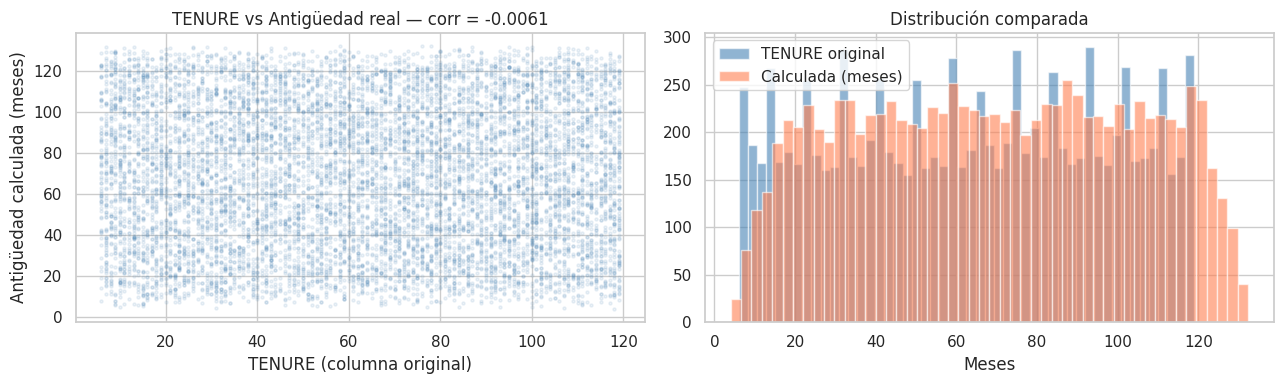


→ Se documenta el hallazgo. Se usará la antigüedad calculada como feature.


In [12]:
# =========================
# Evidencia del Problema 5: TENURE vs antigüedad calculada
# =========================

claims_raw["POLICY_EFF_DT_dt"] = pd.to_datetime(claims_raw["POLICY_EFF_DT"])
claims_raw["TXN_DATE_TIME_dt"] = pd.to_datetime(claims_raw["TXN_DATE_TIME"])
claims_raw["_calc_tenure_months"] = (
    (claims_raw["TXN_DATE_TIME_dt"] - claims_raw["POLICY_EFF_DT_dt"]).dt.days / 30.44
)

corr = claims_raw["TENURE"].corr(claims_raw["_calc_tenure_months"])
print(f"Correlación TENURE vs antigüedad calculada: {corr:.4f}  ← prácticamente CERO")
print(f"")
print(f"TENURE original:      mean={claims_raw['TENURE'].mean():.1f}, min={claims_raw['TENURE'].min()}, max={claims_raw['TENURE'].max()}")
print(f"Antigüedad calculada: mean={claims_raw['_calc_tenure_months'].mean():.1f}, min={claims_raw['_calc_tenure_months'].min():.1f}, max={claims_raw['_calc_tenure_months'].max():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(claims_raw["TENURE"], claims_raw["_calc_tenure_months"], alpha=0.1, s=5, color="steelblue")
axes[0].set_xlabel("TENURE (columna original)")
axes[0].set_ylabel("Antigüedad calculada (meses)")
axes[0].set_title(f"TENURE vs Antigüedad real — corr = {corr:.4f}")

axes[1].hist(claims_raw["TENURE"], bins=50, alpha=0.6, label="TENURE original", color="steelblue")
axes[1].hist(claims_raw["_calc_tenure_months"], bins=50, alpha=0.6, label="Calculada (meses)", color="coral")
axes[1].set_xlabel("Meses")
axes[1].legend()
axes[1].set_title("Distribución comparada")

plt.tight_layout()
plt.savefig("tenure_vs_calculated.png", dpi=150, bbox_inches="tight")
plt.show()

# Limpiar columnas temporales
claims_raw.drop(columns=["POLICY_EFF_DT_dt", "TXN_DATE_TIME_dt", "_calc_tenure_months"], inplace=True)
print("\n→ Se documenta el hallazgo. Se usará la antigüedad calculada como feature.")


# 6. Funciones auxiliares de normalización

Se definen funciones reutilizables para estandarizar las 3 tablas de forma consistente.


In [13]:
# =========================
# 7. Funciones auxiliares de normalización
# =========================

def to_snake_case(column_name: str) -> str:
    """Convierte nombres de columnas a snake_case.
    Ejemplo: 'TXN_DATE_TIME' → 'txn_date_time', 'PolicyEffDt' → 'policy_eff_dt' para estandarizar el modelo."""
    column_name = column_name.strip()
    column_name = re.sub(r"[^A-Za-z0-9]+", "_", column_name)
    column_name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", column_name)
    column_name = re.sub(r"_+", "_", column_name)
    return column_name.strip("_").lower()

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Renombra columnas a snake_case."""
    df = df.copy()
    df.columns = [to_snake_case(col) for col in df.columns]
    return df

def standardize_text_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Limpia columnas de texto preservando nulos."""
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype("string")
                .str.strip()
                .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
            )
    return df

def format_numeric_identifier(series: pd.Series, width: int) -> pd.Series:
    """Convierte identificadores numéricos a texto con padding a la izquierda."""
    return (
        series.astype("Int64")
        .astype("string")
        .str.replace(".0", "", regex=False)
        .str.zfill(width)
    )

def add_missing_flag(df: pd.DataFrame, source_col: str, new_flag_col: str) -> pd.DataFrame:
    """Agrega columna flag (0/1) indicando si el campo fuente es nulo."""
    df = df.copy()
    df[new_flag_col] = df[source_col].notna().astype("Int8")
    return df

print("✅ Funciones de normalización definidas")


✅ Funciones de normalización definidas


# 7. Normalización de las tablas

La normalización **no** busca rearmar el modelo hacia 3FN completa,
sino **dejar las tablas sólidas, tipadas y consistentes** para análisis y reutilización.

Decisiones principales:
- Estandarizar nombres de columnas a `snake_case`.
- Tipificar fechas a `datetime64[ns]`.
- Corregir identificadores mal inferidos como numéricos.
- Preservar nulos cuando son válidos (no imputar por imputar).
- Agregar flags útiles para analytics.

---

### 7.1 Normalización de `claims` (insurance_data)


In [14]:
# =========================
# 8. Normalización de claims
# =========================

# Paso 1: snake_case en todas las columnas
claims = standardize_columns(claims_raw)

# --- Columnas de texto / categóricas ---
claim_text_cols = [
    "transaction_id", "customer_id", "policy_number", "insurance_type", "customer_name",
    "address_line1", "address_line2", "city", "state", "ssn", "marital_status",
    "employment_status", "risk_segmentation", "house_type", "social_class",
    "acct_number", "customer_education_level", "claim_status", "incident_severity",
    "authority_contacted", "incident_state", "incident_city", "agent_id", "vendor_id"
]
claims = standardize_text_columns(claims, claim_text_cols)

# --- Fechas ---
claims["txn_date_time"]  = pd.to_datetime(claims["txn_date_time"],  errors="coerce")
claims["policy_eff_dt"]  = pd.to_datetime(claims["policy_eff_dt"],  errors="coerce")
claims["loss_dt"]        = pd.to_datetime(claims["loss_dt"],        errors="coerce")
claims["report_dt"]      = pd.to_datetime(claims["report_dt"],      errors="coerce")

# --- Identificadores numéricos → texto con padding ---
claims["postal_code"]    = format_numeric_identifier(claims["postal_code"], 5)
claims["routing_number"] = format_numeric_identifier(claims["routing_number"], 9)

# --- Tipado explícito de numéricos ---
numeric_casts = {
    "premium_amount": "float64",
    "claim_amount":   "float64",
    "age":            "Int64",
    "tenure":         "Int64",
    "no_of_family_members": "Int64",
    "any_injury":           "Int8",
    "police_report_available": "Int8",
    "incident_hour_of_the_day": "Int64"
}
for col, dtype in numeric_casts.items():
    claims[col] = claims[col].astype(dtype)

# Paso 6: Imputar nulls en categóricos (justificación en sección 5)
claims["authority_contacted"]      = claims["authority_contacted"].fillna("None")      # No se contactó autoridad
claims["customer_education_level"] = claims["customer_education_level"].fillna("Unknown")  # Dato no recolectado
claims["city"]                     = claims["city"].fillna("Unknown")
claims["incident_city"]            = claims["incident_city"].fillna("Unknown")

# --- Flag de vendor asignado ---
claims = add_missing_flag(claims, "vendor_id", "has_vendor")

print(f"claims normalizado: {claims.shape}")
print(f"Fechas: {[str(claims[c].dtype) for c in ['txn_date_time','loss_dt','report_dt','policy_eff_dt']]}")
print(f"postal_code tipo: {claims['postal_code'].dtype}, ejemplo: {claims['postal_code'].iloc[0]}")
print(f"has_vendor: {claims['has_vendor'].value_counts().to_dict()}")
print(f"Nulls operativos restantes: {claims.drop(columns=['vendor_id','address_line2']).isnull().sum().sum()}")


claims normalizado: (10000, 39)
Fechas: ['datetime64[us]', 'datetime64[us]', 'datetime64[us]', 'datetime64[us]']
postal_code tipo: string, ejemplo: 85308
has_vendor: {np.int8(1): 6755, np.int8(0): 3245}
Nulls operativos restantes: 0


In [15]:
# Validaciones temporales post-parseo
print("=== VALIDACIONES TEMPORALES ===")
print(f"Fechas nulas tras parseo:")
print(claims[["txn_date_time", "policy_eff_dt", "loss_dt", "report_dt"]].isna().sum())

print(f"\nRegistros con report_dt < loss_dt (inconsistencia): {(claims['report_dt'] < claims['loss_dt']).sum()}")
print(f"Registros con loss_dt > txn_date_time:                {(claims['loss_dt'] > claims['txn_date_time']).sum()}")
print(f"Registros con policy_eff_dt > loss_dt:                {(claims['policy_eff_dt'] > claims['loss_dt']).sum()}")
print("\n✅ Sin inconsistencias temporales")


=== VALIDACIONES TEMPORALES ===
Fechas nulas tras parseo:
txn_date_time    0
policy_eff_dt    0
loss_dt          0
report_dt        0
dtype: int64

Registros con report_dt < loss_dt (inconsistencia): 0


Registros con loss_dt > txn_date_time:                0
Registros con policy_eff_dt > loss_dt:                0

✅ Sin inconsistencias temporales


### 7.2 Normalización de `employees` (employee_data)

In [16]:
# =========================
# 9. Normalización de employees
# =========================

employees = standardize_columns(employees_raw)

employee_text_cols = [
    "agent_id", "agent_name", "address_line1", "address_line2",
    "city", "state", "emp_acct_number"
]
employees = standardize_text_columns(employees, employee_text_cols)

# Fecha de ingreso
employees["date_of_joining"] = pd.to_datetime(employees["date_of_joining"], errors="coerce")

# Identificadores numéricos → texto
employees["postal_code"]       = format_numeric_identifier(employees["postal_code"], 5)
employees["emp_routing_number"] = format_numeric_identifier(employees["emp_routing_number"], 9)

# Imputar city null
employees["city"] = employees["city"].fillna("Unknown")

print(f"employees normalizado: {employees.shape}")
print(f"date_of_joining: {employees['date_of_joining'].dtype}")
print(f"Rango: {employees['date_of_joining'].min()} a {employees['date_of_joining'].max()}")
print(f"Nulls (sin address_line2): {employees.drop(columns=['address_line2']).isnull().sum().sum()}")
print("✅ employees limpio")


employees normalizado: (1200, 10)
date_of_joining: datetime64[us]
Rango: 1990-06-25 00:00:00 a 2018-06-24 00:00:00
Nulls (sin address_line2): 0
✅ employees limpio


### 7.3 Normalización de `vendors` (vendor_data)

In [17]:
# =========================
# 10. Normalización de vendors
# =========================

vendors = standardize_columns(vendors_raw)

vendor_text_cols = [
    "vendor_id", "vendor_name", "address_line1", "address_line2",
    "city", "state"
]
vendors = standardize_text_columns(vendors, vendor_text_cols)

# Identificadores numéricos → texto
vendors["postal_code"] = format_numeric_identifier(vendors["postal_code"], 5)

# Imputar city null
vendors["city"] = vendors["city"].fillna("Unknown")

print(f"vendors normalizado: {vendors.shape}")
print(f"Nulls (sin address_line2): {vendors.drop(columns=['address_line2']).isnull().sum().sum()}")
print("✅ vendors limpio")


vendors normalizado: (600, 7)
Nulls (sin address_line2): 0
✅ vendors limpio


# 8. Evidencia concreta de las correcciones aplicadas

In [18]:
# Evidencia Problema 2: ZIP codes con leading zeros restaurados
zip_lengths = claims["postal_code"].dropna().str.len().value_counts().sort_index()
print("=== ZIP CODE — largo de string post-normalización ===")
print(zip_lengths)
print(f"\nEjemplo CT (deben empezar con 0): {claims[claims['state']=='CT']['postal_code'].head(5).tolist()}")
print(f"\n✅ Todos los ZIP codes tienen 5 dígitos")


=== ZIP CODE — largo de string post-normalización ===
postal_code
5    10000
Name: count, dtype: Int64

Ejemplo CT (deben empezar con 0): ['06040', '06040', '06042', '06042', '06042']

✅ Todos los ZIP codes tienen 5 dígitos


In [19]:
# Evidencia Problema 3: resumen de nulls post-normalización
def null_summary(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    result = (
        df.isna().mean()
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
        .head(top_n)
        .to_frame("null_pct")
    )
    result["null_count"] = df.isna().sum().loc[result.index]
    return result

print("=== NULLS POST-NORMALIZACIÓN: claims ===")
display(null_summary(claims))
print("\n=== NULLS POST-NORMALIZACIÓN: employees ===")
display(null_summary(employees, 5))
print("\n=== NULLS POST-NORMALIZACIÓN: vendors ===")
display(null_summary(vendors, 5))


=== NULLS POST-NORMALIZACIÓN: claims ===


,null_pct,null_count
address_line2,85.05,8505
vendor_id,32.45,3245
txn_date_time,0.00,0
policy_number,0.00,0
policy_eff_dt,0.00,0
transaction_id,0.00,0
customer_id,0.00,0
report_dt,0.00,0
loss_dt,0.00,0
claim_amount,0.00,0



=== NULLS POST-NORMALIZACIÓN: employees ===


,null_pct,null_count
address_line2,85.08,1021
agent_id,0.00,0
agent_name,0.00,0
date_of_joining,0.00,0
address_line1,0.00,0



=== NULLS POST-NORMALIZACIÓN: vendors ===


,null_pct,null_count
address_line2,83.83,503
vendor_name,0.00,0
vendor_id,0.00,0
address_line1,0.00,0
city,0.00,0


In [20]:
# Evidencia Problema 4: CLAIM_AMOUNT bucketeado
print("=== CLAIM_AMOUNT — distribución de valores ===")
print(f"Valores únicos: {claims['claim_amount'].nunique()} (sobre {len(claims):,} registros)")
print(f"\nTop 10 valores más frecuentes:")
print(claims["claim_amount"].value_counts().head(10))
print("\n→ Solo 107 valores únicos. Montos claramente bucketeados/tabulados.")


=== CLAIM_AMOUNT — distribución de valores ===
Valores únicos: 107 (sobre 10,000 registros)

Top 10 valores más frecuentes:
claim_amount
1000.00     585
2000.00     584
5000.00     573
4000.00     567
3000.00     563
10000.00    315
600.00      267
700.00      254
7000.00     251
9000.00     247
Name: count, dtype: int64

→ Solo 107 valores únicos. Montos claramente bucketeados/tabulados.


# 9. Feature engineering temporal

La consigna pide al menos 2 features temporales. Se calculan **7 features derivadas** organizadas en dos categorías.

## Features temporales principales (de la consigna)

1. **`days_report_delay`** — Días entre siniestro y reporte.
2. **`policy_age_days_at_loss`** — Antigüedad de la póliza al momento del siniestro (días).
3. **`policy_age_years_at_loss`** — Ídem en años (más interpretable para negocio).

## Features adicionales para analytics y modelado

4. **`loss_ratio`** — `claim_amount / premium_amount`. Desproporción entre lo reclamado y lo pagado.
5. **`out_of_state_incident`** — Flag: el siniestro ocurrió fuera del estado del cliente.
6. **`incident_time_category`** — Franja horaria del incidente (Morning/Afternoon/Evening/Night).
7. **`loss_year_month`** / **`report_year_month`** — Período mensual para evolución temporal.


In [21]:
# =========================
# 11. Features temporales en claims
# =========================

# --- FEATURE 1:
# Lógica: cuánto tardó el cliente en reportar el siniestro.
# Valor fraude: reporte el mismo día (0) = posible preparación previa. Días entre siniestro y reporte ---
claims["days_report_delay"] = (
    (claims["report_dt"] - claims["loss_dt"]).dt.days.astype("Int64")
)

# --- FEATURE 2:
# Lógica: cuántos días tenía la póliza cuando ocurrió el siniestro.
# Valor fraude: pólizas muy nuevas con claims altos = contratación oportunista. Antigüedad de la póliza al momento del siniestro (días) ---
claims["policy_age_days_at_loss"] = (
    (claims["loss_dt"] - claims["policy_eff_dt"]).dt.days.astype("Int64")
)

# --- FEATURE 3: Antigüedad de la póliza (años, más interpretable) ---
claims["policy_age_years_at_loss"] = (
    claims["policy_age_days_at_loss"] / 365.25
).round(2)

# --- FEATURE 4:
# Lógica: cuántas veces el monto reclamado supera la prima pagada.
# Valor fraude: ratios >500x indican desproporción severa. Loss ratio (claim / prima) ---
claims["loss_ratio"] = (
    claims["claim_amount"] / claims["premium_amount"]
).round(2)

# --- FEATURE 5:
# Lógica: 1 si el siniestro ocurrió en un estado diferente al del cliente.
# Valor fraude: siniestros fuera del estado son más difíciles de verificar. Incidente fuera del estado del cliente ---
claims["out_of_state_incident"] = (
    (claims["state"] != claims["incident_state"]).astype("Int8")
)

# --- FEATURE 6:
# Lógica: categoriza la hora en Morning/Afternoon/Evening/Night.
# Valor fraude: siniestros nocturnos (Night) son menos verificables. Franja horaria del incidente ---
def categorize_hour(h):
    if pd.isna(h): return pd.NA
    h = int(h)
    if 6 <= h < 12:   return "Morning"
    elif 12 <= h < 18: return "Afternoon"
    elif 18 <= h < 22: return "Evening"
    else:              return "Night"

claims["incident_time_category"] = (
    claims["incident_hour_of_the_day"].apply(categorize_hour).astype("string")
)

# --- FEATURE 7: Períodos mensuales para evolución temporal ---
claims["loss_year_month"]   = claims["loss_dt"].dt.to_period("M").astype("string")
claims["report_year_month"] = claims["report_dt"].dt.to_period("M").astype("string")

print("✅ 7 features derivadas creadas")
print(f"\nShape actualizado de claims: {claims.shape}")


✅ 7 features derivadas creadas

Shape actualizado de claims: (10000, 47)


In [22]:
# Estadísticas descriptivas de las features temporales principales
print("=== FEATURES TEMPORALES — ESTADÍSTICAS ===\n")

features_check = claims[["days_report_delay", "policy_age_days_at_loss", 
                          "policy_age_years_at_loss", "loss_ratio"]].describe().T
display(features_check)

print(f"\n--- days_report_delay ---")
print(f"  Reportes el mismo día (0 días): {(claims['days_report_delay']==0).sum()} ({(claims['days_report_delay']==0).mean()*100:.1f}%)")
print(f"  Reportes negativos (error):     {(claims['days_report_delay']<0).sum()}")

print(f"\n--- loss_ratio ---")
print(f"  Ratio > 500x: {(claims['loss_ratio'] > 500).sum()}")
print(f"  Ratio > 1000x: {(claims['loss_ratio'] > 1000).sum()}")

print(f"\n--- out_of_state_incident ---")
print(f"  Fuera del estado: {claims['out_of_state_incident'].sum()} ({claims['out_of_state_incident'].mean()*100:.1f}%)")

print(f"\n--- incident_time_category ---")
print(claims["incident_time_category"].value_counts())


=== FEATURES TEMPORALES — ESTADÍSTICAS ===



,count,mean,std,min,25%,50%,75%,max
days_report_delay,10000.00,3.21,1.97,0.00,1.00,3.00,5.00,5.00
policy_age_days_at_loss,10000.00,2096.48,1029.52,110.00,1219.00,2096.00,2981.00,4026.00
policy_age_years_at_loss,10000.00,5.74,2.82,0.30,3.34,5.74,8.16,11.02
loss_ratio,10000.00,199.26,306.04,5.01,38.56,74.47,194.75,1862.54



--- days_report_delay ---
  Reportes el mismo día (0 días): 1565 (15.7%)
  Reportes negativos (error):     0

--- loss_ratio ---
  Ratio > 500x: 1168
  Ratio > 1000x: 455

--- out_of_state_incident ---
  Fuera del estado: 9358 (93.6%)

--- incident_time_category ---


incident_time_category
Night        3262
Afternoon    2538
Morning      2519
Evening      1681
Name: count, dtype: int64[pyarrow]


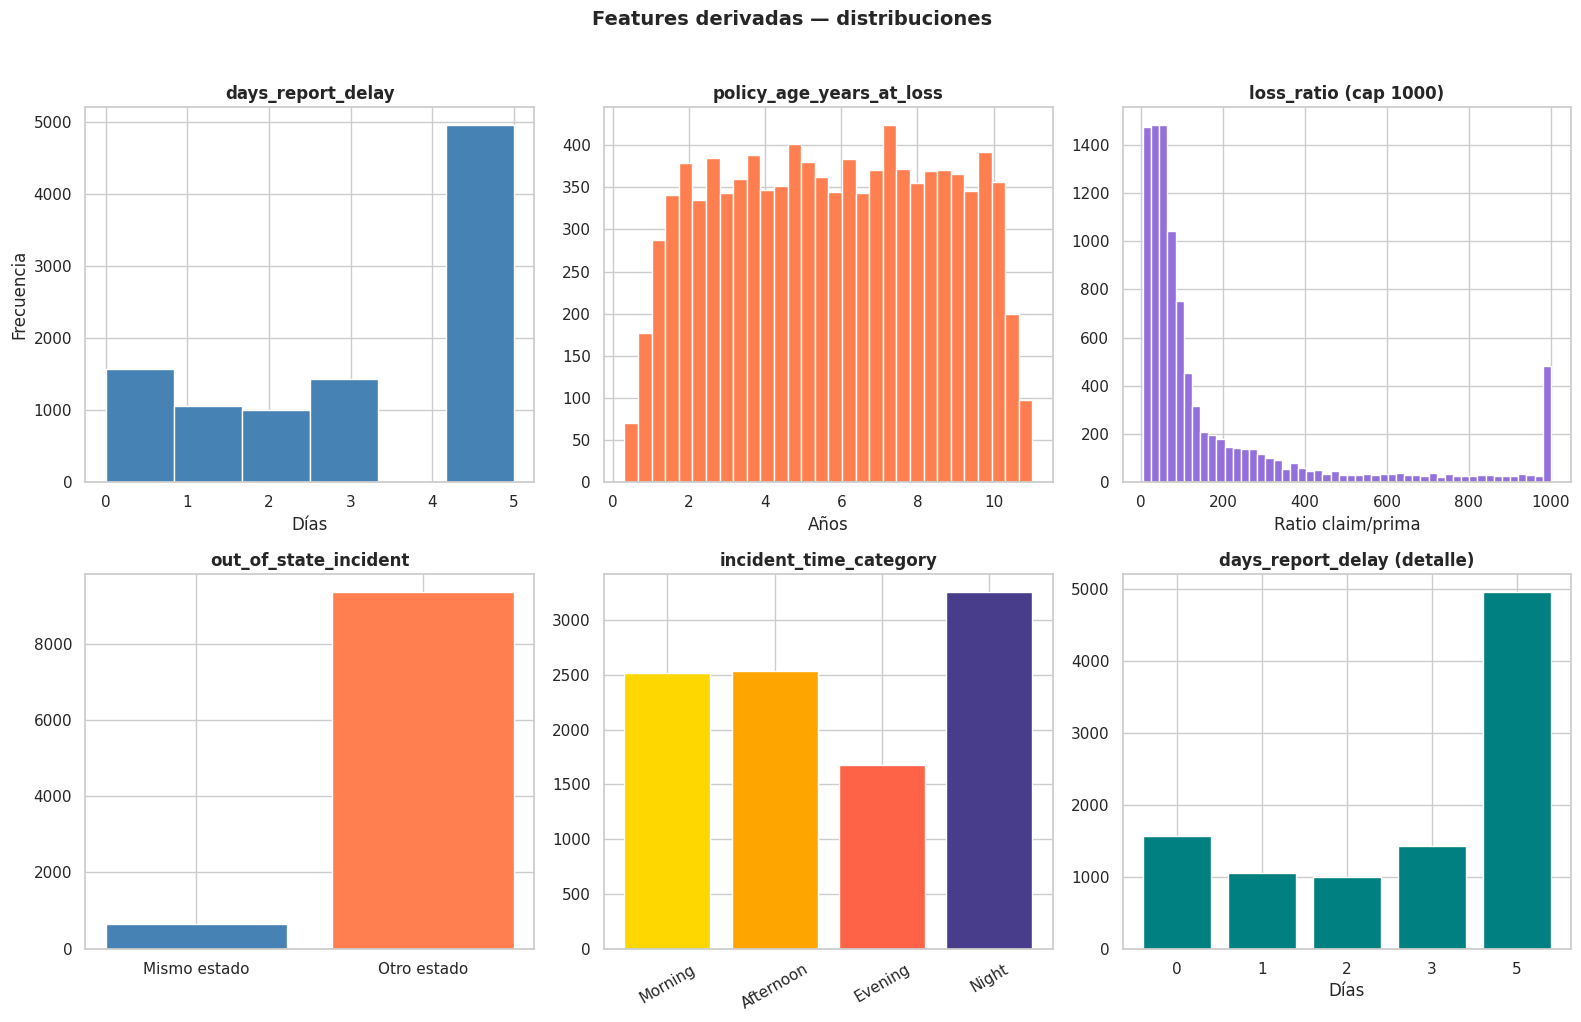

In [23]:
# =========================
# Visualización de features derivadas
# =========================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. days_report_delay
axes[0,0].hist(claims["days_report_delay"].dropna(), bins=6, color="steelblue", edgecolor="white")
axes[0,0].set_title("days_report_delay", fontweight="bold")
axes[0,0].set_xlabel("Días")
axes[0,0].set_ylabel("Frecuencia")

# 2. policy_age_years_at_loss
axes[0,1].hist(claims["policy_age_years_at_loss"].dropna(), bins=30, color="coral", edgecolor="white")
axes[0,1].set_title("policy_age_years_at_loss", fontweight="bold")
axes[0,1].set_xlabel("Años")

# 3. loss_ratio (capped for visibility)
axes[0,2].hist(claims["loss_ratio"].clip(upper=1000).dropna(), bins=50, color="mediumpurple", edgecolor="white")
axes[0,2].set_title("loss_ratio (cap 1000)", fontweight="bold")
axes[0,2].set_xlabel("Ratio claim/prima")

# 4. out_of_state_incident
oos_vals = claims["out_of_state_incident"].value_counts().sort_index()
axes[1,0].bar(["Mismo estado", "Otro estado"], oos_vals.values, color=["steelblue", "coral"])
axes[1,0].set_title("out_of_state_incident", fontweight="bold")

# 5. incident_time_category
cat_order = ["Morning", "Afternoon", "Evening", "Night"]
cat_counts = claims["incident_time_category"].value_counts().reindex(cat_order)
axes[1,1].bar(cat_order, cat_counts.values, color=["gold", "orange", "tomato", "darkslateblue"])
axes[1,1].set_title("incident_time_category", fontweight="bold")
axes[1,1].tick_params(axis="x", rotation=30)

# 6. days_report_delay distribution detail
delay_dist = claims["days_report_delay"].value_counts(dropna=False).sort_index()
axes[1,2].bar(delay_dist.index.astype(str), delay_dist.values, color="teal")
axes[1,2].set_title("days_report_delay (detalle)", fontweight="bold")
axes[1,2].set_xlabel("Días")

plt.suptitle("Features derivadas — distribuciones", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("features_derivadas.png", dpi=150, bbox_inches="tight")
plt.show()


# 10. Integración de tablas maestras con la tabla de claims

Una vez normalizadas las tres fuentes, se construye una **base integrada gold**.
Esta tabla no reemplaza a las tablas maestras: se usa como **dataset analítico** para los siguientes puntos.

## Estrategia de merge
- `claims` se mantiene como tabla base (LEFT JOIN).
- `employees` se incorpora por `agent_id` con columnas renombradas a `_dim`.
- `vendors` se incorpora por `vendor_id` con columnas renombradas a `_dim`.
- Se agrega `agent_tenure_days_at_report` como feature extra del join.


In [24]:
# =========================
# 12. Preparación de dimensiones para merge
# =========================

# Renombrar columnas de employees para evitar ambigüedad
# Employees: renombrar para distinguir datos del agente vs datos del cliente
employees_dim = employees.rename(columns={
    "agent_name":        "agent_name_dim",
    "date_of_joining":   "agent_date_of_joining_dim",
    "address_line1":     "agent_address_dim",
    "address_line2":     "agent_address2_dim",
    "city":              "agent_city_dim",
    "state":             "agent_state_dim",
    "postal_code":       "agent_postal_code_dim",
    "emp_routing_number": "agent_routing_dim",
    "emp_acct_number":    "agent_acct_dim",
})

# Renombrar columnas de vendors
# Vendors: misma lógica de renombrado
vendors_dim = vendors.rename(columns={
    "vendor_name":   "vendor_name_dim",
    "address_line1": "vendor_address_dim",
    "address_line2": "vendor_address2_dim",
    "city":          "vendor_city_dim",
    "state":         "vendor_state_dim",
    "postal_code":   "vendor_postal_code_dim",
})

# LEFT JOIN claims + employees + vendors
# LEFT JOIN: claims como base (LEFT para no perder los 3,245 claims sin vendor)
claims_enriched = claims.merge(employees_dim, on="agent_id", how="left")
claims_enriched = claims_enriched.merge(vendors_dim, on="vendor_id", how="left")

# Feature adicional: antigüedad del agente al momento del claim
# Feature adicional: antigüedad del agente al momento del claim
# Solo es posible después del merge porque necesitamos date_of_joining
claims_enriched["agent_tenure_days_at_report"] = (
    (claims_enriched["txn_date_time"] - claims_enriched["agent_date_of_joining_dim"]).dt.days.astype("Int64")
)

print(f"claims_enriched (gold): {claims_enriched.shape}")


claims_enriched (gold): (10000, 63)


In [25]:
# Validación post-merge
print("=== VALIDACIÓN POST-MERGE ===")
print(f"Filas claims antes:  {len(claims):,}")
print(f"Filas gold después:  {len(claims_enriched):,}")
assert len(claims_enriched) == len(claims), "ERROR: el join multiplicó filas"
print(f"✅ Sin multiplicación de filas")

print(f"\nAgent name null (debe ser 0):  {claims_enriched['agent_name_dim'].isna().sum()}")
print(f"Vendor name null (esperado ~32%): {claims_enriched['vendor_name_dim'].isna().sum()} ({claims_enriched['vendor_name_dim'].isna().mean()*100:.1f}%)")


=== VALIDACIÓN POST-MERGE ===
Filas claims antes:  10,000
Filas gold después:  10,000
✅ Sin multiplicación de filas

Agent name null (debe ser 0):  0
Vendor name null (esperado ~32%): 3245 (32.5%)


# 11. Persistencia de tablas sólidas

## Salidas generadas

### Silver (tablas limpias individuales)
- `claims_silver.parquet` — claims normalizados + features
- `employees_silver.parquet` — maestro agentes limpio
- `vendors_silver.parquet` — maestro vendors limpio

### Gold (dataset integrado)
- `claims_enriched_gold.parquet` — claims + agentes + vendors + features

> Se preservan ambas capas para trazabilidad y reutilización.


In [26]:
# =========================
# 13. Escritura a Parquet
# =========================

CLAIMS_SILVER_PATH    = SILVER_DIR / "claims_silver.parquet"
EMPLOYEES_SILVER_PATH = SILVER_DIR / "employees_silver.parquet"
VENDORS_SILVER_PATH   = SILVER_DIR / "vendors_silver.parquet"
CLAIMS_GOLD_PATH      = GOLD_DIR  / "claims_enriched_gold.parquet"

# Guardar silver (tablas individuales limpias)
claims.to_parquet(CLAIMS_SILVER_PATH, index=False, engine="pyarrow")
employees.to_parquet(EMPLOYEES_SILVER_PATH, index=False, engine="pyarrow")
vendors.to_parquet(VENDORS_SILVER_PATH, index=False, engine="pyarrow")
# Guardar gold (dataset integrado + features + dimensiones)
claims_enriched.to_parquet(CLAIMS_GOLD_PATH, index=False, engine="pyarrow")

print("=== ARCHIVOS PARQUET GENERADOS ===")
for label, path in [
    ("silver/claims",    CLAIMS_SILVER_PATH),
    ("silver/employees", EMPLOYEES_SILVER_PATH),
    ("silver/vendors",   VENDORS_SILVER_PATH),
    ("gold/enriched",    CLAIMS_GOLD_PATH),
]:
    size_kb = path.stat().st_size / 1024
    print(f"  {label:25s} → {size_kb:>8.1f} KB")

# Comparar con CSV original
csv_total = sum(f.stat().st_size for f in BRONZE_DIR.glob("*.csv")) / 1024
parquet_total = sum(f.stat().st_size for f in list(SILVER_DIR.glob("*.parquet")) + list(GOLD_DIR.glob("*.parquet"))) / 1024
print(f"\nCSV total (bronze):     {csv_total:>8.1f} KB")
print(f"Parquet total (silver+gold): {parquet_total:>8.1f} KB")
print(f"Compresión: {(1 - parquet_total/csv_total)*100:.1f}% menos espacio")


=== ARCHIVOS PARQUET GENERADOS ===
  silver/claims             →   1183.1 KB
  silver/employees          →     97.4 KB
  silver/vendors            →     30.0 KB
  gold/enriched             →   1453.7 KB

CSV total (bronze):       3037.6 KB
Parquet total (silver+gold):   2764.2 KB
Compresión: 9.0% menos espacio


In [27]:
# Verificación de re-lectura desde Parquet
claims_check = pd.read_parquet(CLAIMS_SILVER_PATH)

print("=== VERIFICACIÓN POST-PARQUET ===")
print(f"Shape: {claims_check.shape} (esperado: {claims.shape})")
print(f"Fechas preservadas: {[str(claims_check[c].dtype) for c in ['txn_date_time','loss_dt','report_dt']]}")
print(f"postal_code tipo: {claims_check['postal_code'].dtype}")
print(f"\n✅ Parquet OK — tipos y datos preservados")


=== VERIFICACIÓN POST-PARQUET ===
Shape: (10000, 47) (esperado: (10000, 47))
Fechas preservadas: ['datetime64[us]', 'datetime64[us]', 'datetime64[us]']
postal_code tipo: string

✅ Parquet OK — tipos y datos preservados


# 12. Capa SQL sobre las tablas sólidas (DuckDB)

Se crea una base local DuckDB persistida a archivo para que los próximos notebooks puedan consultar con SQL directamente.


In [28]:
# =========================
# 14. Registro de vistas SQL en DuckDB
# =========================

con = duckdb.connect(str(DUCKDB_PATH))

con.execute(f"CREATE OR REPLACE VIEW claims_silver AS SELECT * FROM read_parquet('{CLAIMS_SILVER_PATH.as_posix()}')")
con.execute(f"CREATE OR REPLACE VIEW employees_silver AS SELECT * FROM read_parquet('{EMPLOYEES_SILVER_PATH.as_posix()}')")
con.execute(f"CREATE OR REPLACE VIEW vendors_silver AS SELECT * FROM read_parquet('{VENDORS_SILVER_PATH.as_posix()}')")
con.execute(f"CREATE OR REPLACE VIEW claims_enriched_gold AS SELECT * FROM read_parquet('{CLAIMS_GOLD_PATH.as_posix()}')")

print("✅ Vistas registradas en DuckDB:")
for view in ["claims_silver", "employees_silver", "vendors_silver", "claims_enriched_gold"]:
    count = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
    print(f"   {view}: {count:,} filas")


✅ Vistas registradas en DuckDB:
   claims_silver: 10,000 filas
   employees_silver: 1,200 filas
   vendors_silver: 600 filas
   claims_enriched_gold: 10,000 filas


## Consultas SQL de validación y explotación base

Estas consultas apuntan a las tablas sólidas Parquet y sirven como base para los próximos puntos.


In [29]:
# SQL 1 · Validación de cobertura y faltantes clave

sql_quality = """
SELECT
    COUNT(*) AS total_claims,
    SUM(CASE WHEN vendor_id IS NULL THEN 1 ELSE 0 END) AS claims_sin_vendor,
    ROUND(SUM(CASE WHEN vendor_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_sin_vendor,
    SUM(CASE WHEN claim_status = 'D' THEN 1 ELSE 0 END) AS claims_denied,
    ROUND(SUM(CASE WHEN claim_status = 'D' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_denied
FROM claims_silver
"""

print("=== SQL 1: Validación de cobertura ===")
display(con.execute(sql_quality).df())


=== SQL 1: Validación de cobertura ===


,total_claims,claims_sin_vendor,pct_sin_vendor,claims_denied,pct_denied
0,10000,3245.00,32.45,503.00,5.03


In [30]:
# SQL 2 · Features temporales calculadas con SQL

sql_features = """
SELECT
    transaction_id,
    policy_eff_dt,
    loss_dt,
    report_dt,
    days_report_delay,
    policy_age_days_at_loss,
    ROUND(policy_age_years_at_loss, 2) AS policy_age_years,
    loss_ratio,
    claim_status
FROM claims_silver
WHERE loss_ratio > 500
ORDER BY loss_ratio DESC
LIMIT 10
"""

print("=== SQL 2: Claims con loss_ratio extremo (>500x) ===")
display(con.execute(sql_features).df())


=== SQL 2: Claims con loss_ratio extremo (>500x) ===


,transaction_id,policy_eff_dt,loss_dt,report_dt,days_report_delay,policy_age_days_at_loss,policy_age_years,loss_ratio,claim_status
0,TXN00006897,2016-03-04,2021-02-10,2021-02-15,5,1804,4.94,1862.54,A
1,TXN00005513,2014-08-01,2020-12-22,2020-12-27,5,2335,6.39,1823.36,A
2,TXN00004641,2013-05-30,2020-11-28,2020-11-30,2,2739,7.50,1807.66,A
3,TXN00001351,2013-02-18,2020-07-16,2020-07-19,3,2705,7.41,1800.91,A
4,TXN00008114,2014-08-30,2021-04-16,2021-04-16,0,2421,6.63,1797.39,A
5,TXN00008915,2011-12-17,2021-05-14,2021-05-16,2,3436,9.41,1787.47,A
6,TXN00004302,2011-11-05,2020-11-02,2020-11-07,5,3285,8.99,1786.40,A
7,TXN00005933,2013-05-03,2021-01-06,2021-01-11,5,2805,7.68,1777.62,A
8,TXN00007500,2014-10-24,2021-03-22,2021-03-22,0,2341,6.41,1775.15,A
9,TXN00007272,2010-09-22,2021-03-05,2021-03-08,3,3817,10.45,1771.25,A


In [31]:
# SQL 3 · Resumen por tipo de seguro (preview de KPIs para punto 2)

sql_summary = """
SELECT
    insurance_type,
    COUNT(*) AS total_claims,
    ROUND(SUM(CASE WHEN claim_status = 'D' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS denial_rate_pct,
    ROUND(AVG(claim_amount), 2) AS avg_claim,
    ROUND(AVG(loss_ratio), 2) AS avg_loss_ratio,
    ROUND(AVG(days_report_delay), 2) AS avg_days_to_report,
    ROUND(AVG(out_of_state_incident) * 100, 2) AS pct_out_of_state,
    ROUND(AVG(has_vendor) * 100, 2) AS pct_has_vendor
FROM claims_silver
GROUP BY insurance_type
ORDER BY denial_rate_pct DESC
"""

print("=== SQL 3: Resumen por tipo de seguro ===")
display(con.execute(sql_summary).df())


=== SQL 3: Resumen por tipo de seguro ===


,insurance_type,total_claims,denial_rate_pct,avg_claim,avg_loss_ratio,avg_days_to_report,pct_out_of_state,pct_has_vendor
0,Motor,1574,5.40,5503.81,54.66,3.21,93.77,69.00
1,Travel,1670,5.27,2979.64,41.61,3.18,92.63,68.02
2,Health,1690,5.03,10801.18,75.33,3.21,93.37,66.98
3,Property,1692,4.96,24573.88,213.97,3.25,94.44,65.90
4,Mobile,1692,4.96,406.80,46.98,3.22,93.74,67.67
5,Life,1682,4.58,54386.44,754.01,3.21,93.52,67.84


In [32]:
# SQL 4 · Score de sospecha multi-criterio (preview para punto 2)

sql_suspicion = """
SELECT
    transaction_id,
    insurance_type,
    claim_amount,
    premium_amount,
    loss_ratio,
    days_report_delay,
    ROUND(policy_age_years_at_loss, 2) AS policy_age_years,
    incident_severity,
    any_injury,
    police_report_available,
    has_vendor,
    out_of_state_incident,
    claim_status,
    -- Score: suma de red flags
    (CASE WHEN loss_ratio > 500 THEN 1 ELSE 0 END
     + CASE WHEN days_report_delay = 0 THEN 1 ELSE 0 END
     + CASE WHEN any_injury = 0 AND incident_severity = 'Total Loss' THEN 1 ELSE 0 END
     + CASE WHEN police_report_available = 0 THEN 1 ELSE 0 END
     + CASE WHEN has_vendor = 0 THEN 1 ELSE 0 END
     + CASE WHEN policy_age_years_at_loss < 1 THEN 1 ELSE 0 END
    ) AS suspicion_score
FROM claims_silver
ORDER BY suspicion_score DESC, claim_amount DESC
LIMIT 15
"""

print("=== SQL 4: Top 15 claims más sospechosos ===")
result = con.execute(sql_suspicion).df()
display(result)
print(f"\nScore máximo: {result['suspicion_score'].max()}")


=== SQL 4: Top 15 claims más sospechosos ===


,transaction_id,insurance_type,claim_amount,premium_amount,loss_ratio,days_report_delay,policy_age_years,incident_severity,any_injury,police_report_available,has_vendor,out_of_state_incident,claim_status,suspicion_score
0,TXN00001683,Health,2000.00,183.66,10.89,0,0.63,Total Loss,0,0,0,1,A,5
1,TXN00000117,Life,100000.00,82.01,1219.36,3,0.42,Total Loss,0,0,1,1,A,4
2,TXN00001573,Life,99000.00,88.21,1122.32,5,8.52,Total Loss,0,0,0,1,D,4
3,TXN00003176,Life,99000.00,97.60,1014.34,0,8.77,Minor Loss,0,0,0,1,A,4
4,TXN00009848,Life,99000.00,88.02,1124.74,0,8.15,Major Loss,1,0,0,1,A,4
5,TXN00003563,Life,97000.00,99.67,973.21,0,10.06,Minor Loss,1,0,0,1,A,4
6,TXN00008898,Life,95000.00,55.82,1701.90,0,1.80,Total Loss,1,0,0,1,A,4
7,TXN00009443,Life,93000.00,84.67,1098.38,0,9.07,Total Loss,0,0,1,1,A,4
8,TXN00006831,Life,92000.00,73.52,1251.36,0,1.47,Minor Loss,1,0,0,1,A,4
9,TXN00009832,Life,91000.00,81.50,1116.56,0,5.54,Major Loss,1,0,0,1,A,4



Score máximo: 5


In [33]:
# SQL 5 · DDL para materializar tablas físicas (opcional)
# Las vistas suelen alcanzar, pero si se necesitan tablas físicas internas:

sql_materialize = """
CREATE OR REPLACE TABLE claims_silver_tbl AS SELECT * FROM claims_silver;
CREATE OR REPLACE TABLE employees_silver_tbl AS SELECT * FROM employees_silver;
CREATE OR REPLACE TABLE vendors_silver_tbl AS SELECT * FROM vendors_silver;
CREATE OR REPLACE TABLE claims_enriched_gold_tbl AS SELECT * FROM claims_enriched_gold;
"""

# con.execute(sql_materialize)
print("DDL preparado. Descomentá la ejecución si querés materializar tablas físicas dentro de DuckDB.")


DDL preparado. Descomentá la ejecución si querés materializar tablas físicas dentro de DuckDB.


In [34]:
# Cerrar conexión DuckDB
con.close()
print("✅ Conexión DuckDB cerrada. Archivo persistido en:", DUCKDB_PATH)


✅ Conexión DuckDB cerrada. Archivo persistido en: /home/claude/db/tekne_claims.duckdb


# 13. Resumen técnico de decisiones tomadas

## Decisiones de modelado
- Se tomó `insurance_data` como tabla central del proceso (tabla de hechos).
- `employee_data` y `vendor_data` se trataron como dimensiones maestras.
- Se conservó la granularidad de 1 fila = 1 claim / transacción.

## Decisiones de calidad
- Fechas convertidas explícitamente a datetime con `errors="coerce"`.
- Identificadores numéricos convertidos a texto con padding para preservar formato.
- Nulos preservados cuando representan ausencia legítima del dato.
- Se documentaron 2 hallazgos adicionales: CLAIM_AMOUNT bucketeado y TENURE inconsistente.
- Se agregaron flags donde el faltante es analíticamente relevante.

## Decisiones de persistencia
- Se eligió Parquet como formato sólido.
- Se dejó una capa silver por tabla y una capa gold integrada.
- Se creó una base DuckDB persistida para consultas SQL reutilizables entre notebooks.

## Resultado
Al cerrar este notebook, queda lista una instancia de datos local, limpia y reusable para:
- KPIs y evolución mensual (punto 2),
- Anomalías e insights (punto 2),
- Modelo predictivo (punto 2),
- Demo de LLM (punto 3),
- Resumen ejecutivo (punto 4).


# 14. Checklist de entrega del Punto 1

## Requisitos de la consigna y cobertura

### 1) Integrar las 3 tablas y describir el modelo de datos
**✅ Cumplido**
Se documentó qué representa cada tabla, cómo se relacionan, se validó integridad referencial y se generó `claims_enriched_gold.parquet`.

### 2) Documentar 3 problemas de calidad y cómo se resolvieron
**✅ Cumplido (5 problemas documentados)**
1. Fechas como texto
2. Identificadores numéricos mal tipados (ZIP, routing)
3. Faltantes relevantes en claves y atributos
4. CLAIM_AMOUNT bucketeado (107 valores únicos)
5. TENURE no correlaciona con antigüedad de póliza

### 3) Calcular al menos dos features derivadas temporales
**✅ Cumplido (7 features)**
1. `days_report_delay`
2. `policy_age_days_at_loss`
3. `policy_age_years_at_loss`
4. `loss_ratio`
5. `out_of_state_incident`
6. `incident_time_category`
7. `agent_tenure_days_at_report` (en gold)

### 4) Entregar código reproducible y comentado
**✅ Cumplido**
Setup de entorno, parametrización, extracción, normalización con funciones reutilizables, persistencia, validaciones, consultas SQL base.

---

## Artefactos generados

| Archivo | Capa | Contenido |
|---------|------|-----------|
| `data/bronze/*.csv` | Bronze | CSVs raw extraídos del ZIP |
| `data/silver/claims_silver.parquet` | Silver | Claims normalizados + features |
| `data/silver/employees_silver.parquet` | Silver | Maestro agentes limpio |
| `data/silver/vendors_silver.parquet` | Silver | Maestro vendors limpio |
| `data/gold/claims_enriched_gold.parquet` | Gold | Dataset integrado (input puntos 2, 3 y 4) |
| `db/tekne_claims.duckdb` | SQL | Base DuckDB con vistas sobre los Parquet |


In [35]:
# =========================
# 15. Cierre
# =========================

print("Notebook Punto 1 finalizado correctamente.")
print("\nArtefactos listos para los siguientes puntos:")
for p in [CLAIMS_SILVER_PATH, EMPLOYEES_SILVER_PATH, VENDORS_SILVER_PATH, CLAIMS_GOLD_PATH, DUCKDB_PATH]:
    print(f"  ✅ {p}")


Notebook Punto 1 finalizado correctamente.

Artefactos listos para los siguientes puntos:
  ✅ /home/claude/data/silver/claims_silver.parquet
  ✅ /home/claude/data/silver/employees_silver.parquet
  ✅ /home/claude/data/silver/vendors_silver.parquet
  ✅ /home/claude/data/gold/claims_enriched_gold.parquet
  ✅ /home/claude/db/tekne_claims.duckdb
